# `preprocessing.ipynb` — ERA5 Caribe/Colombia · Anomalías T2M (1976–2025)

**Autores:** Mateo Gómez · Miguel Jaimes · David Ibáñez — Universidad del Norte, 2026

Este notebook:
1. Procesa el dataset ERA5 y genera todos los artefactos necesarios para `modeling.ipynb`.
2. Exporta automáticamente `preprocesamiento.py` con las funciones reutilizables.
3. Implementa split correcto por **fecha del target** (input_date + horizon).
4. Garantiza cero leakage en climatología, normalización y CV.

> **Solo datos reales ERA5. Resultados válidos como evidencia científica.**


## Carga de datos

In [1]:
import os, sys, json, pickle, warnings, textwrap
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats as sp_stats
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)

# ── Rutas ─────────────────────────────────────────────────────────────────────
NC_PATH    = Path(r"C:\Users\Hp\Documents\era5_caribe_mensual_1976_2025_UNIFICADO.nc")
OUTPUT_DIR = Path("outputs_preprocessing")
RONI_PATH= Path(r"C:\Users\Hp\Documents\Seminario\docs\RONI.ascii.txt")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Parámetros temporales ─────────────────────────────────────────────────────
T_TOTAL     = 600        # 1976-01 → 2025-12 (validado en EDA)
CLIM_START  = "1976"     # Período WMO (pre-aceleración calentamiento)
CLIM_END    = "2005"
TEST_MONTHS = 60         # 2021-01 → 2025-12 — holdout estricto
VAL_MONTHS  = 60         # 2016-01 → 2020-12 — selección de modelos
HORIZON     = 3          # meses adelante (estacional; ACF t2m justifica h≤6)

# ── Variables ERA5 ───────────────────────────────────────────────────────────
VARS_NO_STEP = ["t2m", "sst", "msl", "u10", "v10"]
VARS_STEP    = ["tp", "ssr", "strd", "slhf"]   # acumuladas → suma sobre step
TARGET       = "t2m"
# ssrd eliminada (corr=1.00 con ssr) y e eliminada (corr=1.00 con slhf) — EDA VIF
FEATURES     = ["sst", "msl", "u10", "v10", "tp", "ssr", "strd", "slhf"]

# ── Lags diferenciados (motivación física, EDA ACF/PACF) ─────────────────────
LAG_CONFIG = {
    "sst"  : [1, 2, 3, 6, 12],   # inercia oceánica — ACF hasta lag 12
    "t2m"  : [1, 2, 3, 6, 12],   # autorregresivo — ACF hasta lag 12
    "roni" : [1, 2, 3, 6],
    "strd" : [1, 2, 3, 6],
    "tp"   : [1, 2, 3, 6],
    "u10"  : [1, 2, 3],
    "v10"  : [1, 2, 3],
    "msl"  : [1, 2, 3],
    "ssr"  : [1, 2, 3],
    "slhf" : [1, 2, 3],
}

# ── Block CV ──────────────────────────────────────────────────────────────────
CV_N_SPLITS = 5
CV_GAP      = 12   # gap=12: ACF climática significativa hasta lag ~12m (EDA)

# ── trend_idx ────────────────────────────────────────────────────────────────
# Se construye como np.linspace(0, 1, n_samples) sobre la serie completa.
# Representa el calentamiento secular documentado por Mann-Kendall en el EDA
# (+0.21 K/dec en t2m). Se guarda en metadata su definición exacta.
TREND_IDX_START = "1976-01"    # primer mes de la serie (para reproducibilidad)

print("=" * 60)
print("  PREPROCESSING ERA5 — Caribe/Colombia 1976–2025")
print("=" * 60)
print(f"  NC_PATH     : {NC_PATH}")
print(f"  OUTPUT_DIR  : {OUTPUT_DIR}")
print(f"  HORIZON     : {HORIZON} meses")
print(f"  TEST        : {TEST_MONTHS}m  VAL: {VAL_MONTHS}m  TRAIN: {T_TOTAL-TEST_MONTHS-VAL_MONTHS}m")
print(f"  CV GAP      : {CV_GAP}m  |  N_SPLITS: {CV_N_SPLITS}")
print(f"  CLIM REF    : {CLIM_START}–{CLIM_END} ∩ train (sin leakage)")


  PREPROCESSING ERA5 — Caribe/Colombia 1976–2025
  NC_PATH     : C:\Users\Hp\Documents\era5_caribe_mensual_1976_2025_UNIFICADO.nc
  OUTPUT_DIR  : outputs_preprocessing
  HORIZON     : 3 meses
  TEST        : 60m  VAL: 60m  TRAIN: 480m
  CV GAP      : 12m  |  N_SPLITS: 5
  CLIM REF    : 1976–2005 ∩ train (sin leakage)


In [2]:
# ── Carga y reducción de step ─────────────────────────────────────────────────
assert NC_PATH.exists(), f"Archivo no encontrado: {NC_PATH}"
ds = xr.open_dataset(NC_PATH)

for var in VARS_STEP:
    if var in ds and "step" in ds[var].dims:
        ds[var] = ds[var].sum(dim="step", skipna=True)

time_index = pd.to_datetime(ds.time.values)
assert len(time_index) == T_TOTAL, (
    f"Esperados {T_TOTAL} meses, encontrados {len(time_index)}."
)

print(f"Dataset: {ds.dims}")
print(f"Rango  : {time_index[0].date()} → {time_index[-1].date()}  ({len(time_index)}m)")
print(f"Rango temporal validado")
def load_roni(roni_path: str, date_start: str = "1976-01",
              date_end: str = "2025-12") -> pd.Series:
    """
    RONI de NOAA — formato: SEAS  YR  ANOM (3 columnas, sin TOTAL)
    Diferencia con ONI: no tiene columna TOTAL — índice en columna 2, no 3.
    """
    SEAS_TO_MONTH = {
        "DJF": 1, "JFM": 2, "FMA": 3, "MAM": 4,
        "AMJ": 5, "MJJ": 6, "JJA": 7, "JAS": 8,
        "ASO": 9, "SON": 10, "OND": 11, "NDJ": 12,
    }

    rows = []
    with open(roni_path, encoding="utf-8-sig") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 3 or parts[0] not in SEAS_TO_MONTH:
                continue          # salta encabezado y líneas vacías
            seas = parts[0]
            yr   = int(parts[1])
            anom = float(parts[2])   # ← columna 2, no 3
            rows.append({"year": yr, "month": SEAS_TO_MONTH[seas], "roni": anom})

    print(f"  Filas parseadas: {len(rows)}")

    df_roni = pd.DataFrame(rows)
    df_roni["date"] = pd.to_datetime(
        {"year": df_roni["year"], "month": df_roni["month"], "day": 1}
    )
    df_roni = df_roni.drop_duplicates("date").set_index("date").sort_index()

    idx_full    = pd.date_range(date_start, date_end, freq="MS")
    roni_series = df_roni["roni"].reindex(idx_full).interpolate(method="time")

    assert roni_series.isna().sum() == 0, \
        f"RONI tiene NaN — el archivo no cubre {date_start}→{date_end}"

    print(f"  RONI cargado: {roni_series.index[0].date()} → "
          f"{roni_series.index[-1].date()}")
    print(f"  Rango: [{roni_series.min():.2f}, {roni_series.max():.2f}]  "
          f"σ={roni_series.std():.3f}")
    return roni_series
# ── Integridad ────────────────────────────────────────────────────────────────
print("\n=== INTEGRIDAD ===")
for var in FEATURES + [TARGET]:
    if var in ds:
        n_nan = int(ds[var].isnull().sum())
        tag = " (NaN oceánicos — esperado)" if var == "sst" and n_nan > 0 else ""
        print(f"  {var:<8}: {n_nan:>10,} NaN{tag}")


Dataset: FrozenMappingWarningOnValuesAccess({'step': 12, 'latitude': 73, 'longitude': 65, 'time': 600})
Rango  : 1976-01-01 → 2025-12-01  (600m)
Rango temporal validado

=== INTEGRIDAD ===
  sst     :  2,010,600 NaN (NaN oceánicos — esperado)
  msl     :          0 NaN
  u10     :          0 NaN
  v10     :          0 NaN
  tp      :          0 NaN
  ssr     :          0 NaN
  strd    :          0 NaN
  slhf    :          0 NaN
  t2m     :          0 NaN


In [3]:
# ── Promedio espacial → series 1D ─────────────────────────────────────────────
def spatial_mean(ds, variables, time_index):
    data = {}
    for var in variables:
        if var not in ds:
            continue
        arr    = ds[var]
        sp     = [d for d in ["latitude", "longitude"] if d in arr.dims]
        data[var] = arr.mean(dim=sp, skipna=True).values if sp else arr.values
    df = pd.DataFrame(data, index=time_index)
    df.index.name = "time"
    n_nan = df.isna().sum()
    if n_nan.sum() > 0:
        df = df.interpolate(method="time", limit_direction="both")
        print("  NaN imputados por interpolación lineal:")
        for col in df.columns:
            if n_nan[col] > 0:
                print(f"    {col}: {n_nan[col]} → {df[col].isna().sum()}")
    assert df.isna().sum().sum() == 0, "NaN residuales tras imputación"
    return df.sort_index()

df_raw = spatial_mean(ds, [TARGET] + FEATURES, time_index)
print(f"DataFrame: {df_raw.shape}")
df_raw.describe().round(4)


DataFrame: (600, 9)


,t2m,sst,msl,u10,v10,tp,ssr,strd,slhf
count,600.0000,600.0000,600.0000,600.0000,600.0000,600.0000,6.000000e+02,6.000000e+02,6.000000e+02
mean,297.9096,300.3181,101147.5469,-0.7425,-0.2790,0.0038,7.693591e+06,1.761379e+07,-4.188290e+06
std,0.5487,0.6198,90.3058,0.4663,0.6122,0.0009,5.408206e+05,1.758951e+05,2.857795e+05
min,296.5496,298.6006,100907.3125,-1.7792,-1.5362,0.0011,6.396513e+06,1.704058e+07,-4.849683e+06
25%,297.5473,299.9102,101085.1191,-1.1018,-0.8665,0.0032,7.310394e+06,1.752116e+07,-4.409025e+06
50%,297.8699,300.3443,101136.5781,-0.7369,-0.0796,0.0039,7.684014e+06,1.762778e+07,-4.176876e+06
75%,298.2376,300.7341,101209.0176,-0.3979,0.2495,0.0044,8.070790e+06,1.773584e+07,-3.960422e+06
max,299.6977,302.2169,101398.0625,0.5829,0.7164,0.0056,9.443648e+06,1.813644e+07,-3.562258e+06


In [4]:
# ── División temporal (por fecha del INPUT, no del target) ────────────────────
# El split correcto por fecha del TARGET se implementa en build_features_and_split
# usando: target_date = input_date + HORIZON
# Aquí definimos los límites en términos de fecha de INPUT.
n_total   = len(df_raw)
train_end = n_total - TEST_MONTHS - VAL_MONTHS   # 480
val_end   = n_total - TEST_MONTHS                # 540

t_train = df_raw.index[:train_end]
t_val   = df_raw.index[train_end:val_end]
t_test  = df_raw.index[val_end:]

print(f"INPUT dates:")
print(f"  Train: {t_train[0].date()} → {t_train[-1].date()}  ({len(t_train)}m)")
print(f"  Val  : {t_val[0].date()}   → {t_val[-1].date()}  ({len(t_val)}m)")
print(f"  Test : {t_test[0].date()}  → {t_test[-1].date()}  ({len(t_test)}m)")
print(f"  Total: {n_total}m")


INPUT dates:
  Train: 1976-01-01 → 2015-12-01  (480m)
  Val  : 2016-01-01   → 2020-12-01  (60m)
  Test : 2021-01-01  → 2025-12-01  (60m)
  Total: 600m


  Climatología: 1976–2005 ∩ train (360m de referencia)


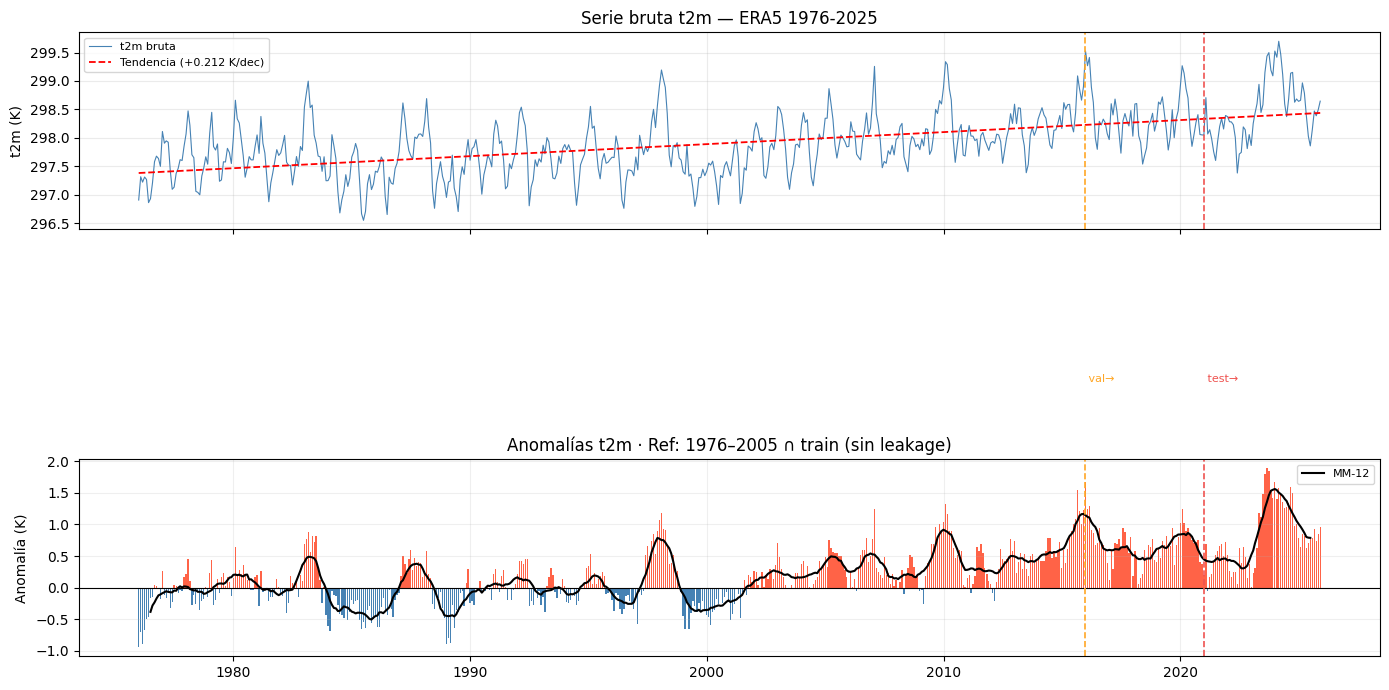

In [5]:
# ── Visualización: serie bruta + anomalías con límites ───────────────────────
def compute_anomalies(df_full, train_end_idx, clim_start, clim_end):
    df_train = df_full.iloc[:train_end_idx]
    df_ref   = df_train.loc[clim_start:clim_end]
    if len(df_ref) == 0:
        print(f"  AVISO: {clim_start}-{clim_end} no intersecta train → usando todo train")
        df_ref = df_train
    clim = df_ref.groupby(df_ref.index.month).mean()
    print(f"  Climatología: {clim_start}–{clim_end} ∩ train ({len(df_ref)}m de referencia)")
    df_anom = df_full.copy()
    for m in range(1, 13):
        mask = df_full.index.month == m
        df_anom.loc[mask] = df_full.loc[mask].values - clim.loc[m].values
    return df_anom, clim

df_anom, clim_df = compute_anomalies(df_raw, train_end, CLIM_START, CLIM_END)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax = axes[0]
ax.plot(df_raw.index, df_raw[TARGET], color="steelblue", lw=0.8, label="t2m bruta")
xn = np.arange(len(df_raw))
sl, ic, *_ = sp_stats.linregress(xn, df_raw[TARGET].values)
ax.plot(df_raw.index, sl*xn + ic, "r--", lw=1.3,
        label=f"Tendencia (+{sl*12*10:.3f} K/dec)")
for idx, label, color in [(train_end,"val→","#FFA726"),(val_end,"test→","#EF5350")]:
    ax.axvline(df_raw.index[idx], color=color, lw=1.2, ls="--")
    ax.text(df_raw.index[idx], df_raw[TARGET].max()*0.98, f" {label}", color=color, fontsize=8)
ax.set_ylabel("t2m (K)"); ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax.set_title("Serie bruta t2m — ERA5 1976-2025")

ax2 = axes[1]
vals = df_anom[TARGET].values
ax2.bar(df_anom.index, vals,
        color=np.where(vals >= 0, "tomato", "steelblue"), width=20, linewidth=0)
ax2.plot(df_anom.index,
         pd.Series(vals, index=df_anom.index).rolling(12, center=True).mean(),
         "k-", lw=1.5, label="MM-12")
ax2.axhline(0, color="black", lw=0.8)
for idx, color in [(train_end,"#FFA726"),(val_end,"#EF5350")]:
    ax2.axvline(df_raw.index[idx], color=color, lw=1.2, ls="--")
ax2.set_ylabel("Anomalía (K)"); ax2.legend(fontsize=8); ax2.grid(alpha=0.2)
ax2.set_title(f"Anomalías t2m · Ref: {CLIM_START}–{CLIM_END} ∩ train (sin leakage)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_anomalias_t2m.png", dpi=150, bbox_inches="tight")
plt.show()


## Feature engenieering

In [6]:
# ── Build features con split correcto por fecha del TARGET ────────────────────
def build_features(df_anom, lag_config, target="t2m"):
    n    = len(df_anom)
    feat = pd.DataFrame(index=df_anom.index)
    # Lags por variable (no incluye target como feature directa)
    for var, lags in lag_config.items():
        if var not in df_anom.columns or var == target:
            continue
        for lag in lags:
            feat[f"{var}_lag{lag}"] = df_anom[var].shift(lag)
    # Lags autoregresivos de t2m
    for lag in lag_config.get(target, [1, 2, 3, 6, 12]):
        feat[f"{target}_lag{lag}"] = df_anom[target].shift(lag)
    # Rolling means (shift(1) → sin contemporáneo)
    for var in ["sst", target]:
        if var in df_anom.columns:
            s = df_anom[var].shift(1)
            feat[f"{var}_roll3"] = s.rolling(3, min_periods=2).mean()
            feat[f"{var}_roll6"] = s.rolling(6, min_periods=3).mean()
    # Cíclicas mensuales
    feat["month_sin"] = np.sin(2 * np.pi * df_anom.index.month / 12)
    feat["month_cos"] = np.cos(2 * np.pi * df_anom.index.month / 12)
    # Tendencia lineal (calentamiento secular +0.21K/dec — Mann-Kendall EDA)
    feat["trend_idx"] = np.linspace(0, 1, n)
    return feat
# ── Cargar RONI (efectivo feb 2026, reemplaza ONI oficial) ────────────────────
roni = load_roni(
    RONI_PATH,                    # "data/RONI.ascii.txt"
    date_start=str(df_raw.index[0])[:7],
    date_end=str(df_raw.index[-1])[:7],
)
roni_safe = roni.shift(1)
df_anom["roni"] = roni_safe
df_anom["roni"] = roni.reindex(df_anom.index)
# Verificar alineación
assert df_anom["roni"].isna().sum() == 0, "RONI tiene NaN tras alineación"
print(f"  RONI integrado: {df_anom['roni'].describe().round(3).to_dict()}")

# ── Build features ────────────────────────────────────────────────────────────
feat_df = build_features(df_anom, LAG_CONFIG, TARGET)
feat_df= build_features(df_anom, LAG_CONFIG, TARGET)
TARGET_COL= f"{TARGET}_target"
# TARGET en t + HORIZON: fecha del target = fecha del input + HORIZON meses
# --- TARGET ORIGINAL (para modelos tabulares) ---
feat_df[TARGET_COL] = df_anom[TARGET].shift(-HORIZON)
# --- TARGET DIFERENCIAL (para DL) ---
TARGET_DIFF_COL = f"{TARGET}_diff_target"
feat_df[TARGET_DIFF_COL] = (
    df_anom[TARGET].shift(-HORIZON) - df_anom[TARGET]
)
feat_df= feat_df.dropna()
FEATURE_COLS = [
    c for c in feat_df.columns
    if c not in [TARGET_COL, TARGET_DIFF_COL]
]

# ── SPLIT CORRECTO POR FECHA DEL TARGET ──────────────────────────────────────
# La muestra con input_date=d tiene target_date = d + HORIZON meses.
# Para que ningún target futuro contamine train ni val, el split se hace así:
#   - train: muestras cuyo TARGET DATE  < t_cutoff_val
#   - val  : muestras cuyo TARGET DATE in [t_cutoff_val, t_cutoff_test)
#   - test : muestras cuyo TARGET DATE >= t_cutoff_test
# Esto equivale a: input_date < t_cutoff_val - HORIZON
# que es lo que implementamos abajo usando target_date directamente.

# Fechas del target para cada muestra
offset      = pd.DateOffset(months=HORIZON)
target_dates = feat_df.index + offset     # target_date = input_date + h

t_cutoff_val  = df_raw.index[train_end]    # 2016-01-01
t_cutoff_test = df_raw.index[val_end]      # 2021-01-01

mask_train = target_dates < t_cutoff_val
mask_val   = (target_dates >= t_cutoff_val) & (target_dates < t_cutoff_test)
mask_test  = target_dates >= t_cutoff_test

X_train_raw = feat_df.loc[mask_train, FEATURE_COLS].values
y_train_raw = feat_df.loc[mask_train, TARGET_COL].values
X_val_raw   = feat_df.loc[mask_val,   FEATURE_COLS].values
y_val_raw   = feat_df.loc[mask_val,   TARGET_COL].values
X_test_raw  = feat_df.loc[mask_test,  FEATURE_COLS].values
y_test_raw  = feat_df.loc[mask_test,  TARGET_COL].values
# --- TARGET DIFERENCIAL (DL) ---
y_train_diff_raw = feat_df.loc[mask_train, TARGET_DIFF_COL].values
y_val_diff_raw   = feat_df.loc[mask_val,   TARGET_DIFF_COL].values
y_test_diff_raw  = feat_df.loc[mask_test,  TARGET_DIFF_COL].values
t_train_idx  = feat_df.index[mask_train]
t_val_idx    = feat_df.index[mask_val]
t_test_idx   = feat_df.index[mask_test]
y_train_base_raw = df_anom.loc[t_train_idx, TARGET].values
y_val_base_raw   = df_anom.loc[t_val_idx,   TARGET].values
y_test_base_raw  = df_anom.loc[t_test_idx,  TARGET].values
td_train     = target_dates[mask_train]
td_val       = target_dates[mask_val]
td_test      = target_dates[mask_test]

n_discarded  = len(feat_df) - len(X_train_raw) - len(X_val_raw) - len(X_test_raw)

print("Split por TARGET DATE (input + HORIZON):")
print(f"  Train: input {t_train_idx[0].date()} → {t_train_idx[-1].date()} "
      f"| target {td_train[0].date()} → {td_train[-1].date()} ({len(X_train_raw)})")
print(f"  Val  : input {t_val_idx[0].date()}   → {t_val_idx[-1].date()} "
      f"| target {td_val[0].date()}   → {td_val[-1].date()}   ({len(X_val_raw)})")
print(f"  Test : input {t_test_idx[0].date()}  → {t_test_idx[-1].date()} "
      f"| target {td_test[0].date()}  → {td_test[-1].date()}  ({len(X_test_raw)})")
print(f"  Muestras descartadas por horizon/lag: {n_discarded}")
print(f"  Features: {len(FEATURE_COLS)}")


  Filas parseadas: 914
  RONI cargado: 1976-01-01 → 2025-12-01
  Rango: [-1.94, 2.52]  σ=0.882
  RONI integrado: {'count': 600.0, 'mean': -0.008, 'std': 0.882, 'min': -1.94, '25%': -0.612, '50%': -0.075, '75%': 0.52, 'max': 2.52}
Split por TARGET DATE (input + HORIZON):
  Train: input 1977-01-01 → 2015-09-01 | target 1977-04-01 → 2015-12-01 (465)
  Val  : input 2015-10-01   → 2020-09-01 | target 2016-01-01   → 2020-12-01   (60)
  Test : input 2020-10-01  → 2025-09-01 | target 2021-01-01  → 2025-12-01  (60)
  Muestras descartadas por horizon/lag: 0
  Features: 44


## Normalizacion y splits

se realiza la normalizacion de los datos utilizando standard scaler para el modelado 

In [7]:
# ── Normalización — fit SOLO sobre train ─────────────────────────────────────
scaler_X = StandardScaler()
scaler_y = StandardScaler()
scaler_y_diff = StandardScaler()
X_train = scaler_X.fit_transform(X_train_raw)
X_val   = scaler_X.transform(X_val_raw)
X_test  = scaler_X.transform(X_test_raw)

y_train = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_val   = scaler_y.transform(y_val_raw.reshape(-1, 1)).ravel()
y_test  = scaler_y.transform(y_test_raw.reshape(-1, 1)).ravel()
y_train_diff = scaler_y_diff.fit_transform(
    y_train_diff_raw.reshape(-1, 1)
).ravel()

y_val_diff = scaler_y_diff.transform(
    y_val_diff_raw.reshape(-1, 1)
).ravel()

y_test_diff = scaler_y_diff.transform(
    y_test_diff_raw.reshape(-1, 1)
).ravel()

print("Normalización (fit=train):")
print(f"  X_train: μ={X_train.mean():.5f}  σ={X_train.std():.5f}  ← esperado ≈ (0,1)")
print(f"  X_val  : μ={X_val.mean():.4f}  (no centrado — correcto)")
print(f"  X_test : μ={X_test.mean():.4f}  (no centrado — correcto)")
print(f"  y_train: μ={y_train.mean():.5f}  σ={y_train.std():.5f}")


Normalización (fit=train):
  X_train: μ=0.00000  σ=1.00000  ← esperado ≈ (0,1)
  X_val  : μ=0.5336  (no centrado — correcto)
  X_test : μ=0.6415  (no centrado — correcto)
  y_train: μ=0.00000  σ=1.00000


## Block Time Series CV con gap (implementación propia)

Se implementó una estrategia de Block Cross-Validation para series temporales sobre el conjunto de entrenamiento (X_train), utilizando una función personalizada:

block_timeseries_cv(n_samples, n_splits, gap)
**Características del esquema**
- Bloques secuenciales (sin aleatoriedad)
Los folds respetan estrictamente el orden temporal.

- **Entrenamiento expansivo (forward chaining)**
En cada fold, el conjunto de entrenamiento crece progresivamente:

Fold 1: [0 → t1]
Fold 2: [0 → t2]
Fold 3: [0 → t3]
- Gap temporal (gap) entre train y validation
    Se introduce una separación explícita para evitar data leakage debido a:
    - autocorrelación temporal
    - uso de lags
    - horizonte de predicción (target shift)
Bloques de validación del mismo tamaño base
Cada fold valida sobre un segmento futuro no solapado.
Sin overlap garantizado
Se verifica que train ∩ validation = ∅ en todos los folds.

In [8]:
# ── Block CV — sobre samples de TRAIN con target correcto ────────────────────
def block_timeseries_cv(n_samples, n_splits, gap):
    """Block CV con gap temporal. Folds sobre samples válidos (post-horizon)."""
    block = (n_samples - gap * n_splits) // (n_splits + 1)
    assert block > 0, f"block={block} ≤ 0. Reducir n_splits o gap."
    splits = []
    for i in range(n_splits):
        tr_end    = block * (i + 1)
        val_start = tr_end + gap
        val_end   = min(val_start + block, n_samples)
        if val_end > val_start:
            splits.append((np.arange(0, tr_end), np.arange(val_start, val_end)))
    return splits

cv_splits = block_timeseries_cv(len(X_train), CV_N_SPLITS, CV_GAP)

print(f"Block CV: {len(cv_splits)} folds | gap={CV_GAP}m | n_train={len(X_train)}")
for i, (tr, va) in enumerate(cv_splits):
    assert len(np.intersect1d(tr, va)) == 0
    print(f"  Fold {i+1}: train=[0:{len(tr)}] ({len(tr)}m) | val=[{va[0]}:{va[-1]+1}] ({len(va)}m)")
print("\n Sin overlap en ningún fold")


Block CV: 5 folds | gap=12m | n_train=465
  Fold 1: train=[0:67] (67m) | val=[79:146] (67m)
  Fold 2: train=[0:134] (134m) | val=[146:213] (67m)
  Fold 3: train=[0:201] (201m) | val=[213:280] (67m)
  Fold 4: train=[0:268] (268m) | val=[280:347] (67m)
  Fold 5: train=[0:335] (335m) | val=[347:414] (67m)

 Sin overlap en ningún fold


## Guardado y exportacion 

se guardan los archivos preprocesados para volver a ser utilizados en las otras partes del proyecto

In [9]:
# ── Guardado de artefactos ────────────────────────────────────────────────────
np.savez_compressed(
    OUTPUT_DIR / "sequences.npz",
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    y_train_raw=y_train_raw,
    y_val_raw=y_val_raw,
    y_test_raw=y_test_raw,
    # target diferencial
    y_train_diff=y_train_diff,
    y_val_diff=y_val_diff,
    y_test_diff=y_test_diff,
    y_train_diff_raw=y_train_diff_raw,
    y_val_diff_raw=y_val_diff_raw,
    y_test_diff_raw=y_test_diff_raw,
    # ── AGREGAR: y_base = t2m(t) en K, para reconstrucción en evaluation ──
    y_train_base_raw=y_train_base_raw,
    y_val_base_raw=y_val_base_raw,
    y_test_base_raw=y_test_base_raw,
    # fechas
    target_dates_train=np.array(td_train.strftime("%Y-%m-%d"), dtype=str),
    target_dates_val=np.array(td_val.strftime("%Y-%m-%d"),     dtype=str),
    target_dates_test=np.array(td_test.strftime("%Y-%m-%d"),   dtype=str),
)
print("sequences.npz  (incluye target_dates_*)")

with open(OUTPUT_DIR / "scaler_X.pkl", "wb") as f: pickle.dump(scaler_X, f)
with open(OUTPUT_DIR / "scaler_y.pkl", "wb") as f: pickle.dump(scaler_y, f)
with open(OUTPUT_DIR / "scaler_y_diff.pkl", "wb") as f:
    pickle.dump(scaler_y_diff, f)

print("scaler_X.pkl | scaler_y.pkl")
print(" scaler_y_diff.pkl")
clim_df.to_csv(OUTPUT_DIR / "climatologia.csv")
print("climatologia.csv")

with open(OUTPUT_DIR / "cv_splits.pkl", "wb") as f: pickle.dump(cv_splits, f)
print("cv_splits.pkl")

meta = {
    "horizon"             : HORIZON,
    "target"              : TARGET,
    "feature_cols"        : FEATURE_COLS,
    "n_features"          : len(FEATURE_COLS),
    "clim_period"         : [CLIM_START, CLIM_END],
    "train_input_period"  : [str(t_train_idx[0].date()), str(t_train_idx[-1].date())],
    "train_target_period" : [str(td_train[0].date()),    str(td_train[-1].date())],
    "val_input_period"    : [str(t_val_idx[0].date()),   str(t_val_idx[-1].date())],
    "val_target_period"   : [str(td_val[0].date()),      str(td_val[-1].date())],
    "test_input_period"   : [str(t_test_idx[0].date()),  str(t_test_idx[-1].date())],
    "test_target_period"  : [str(td_test[0].date()),     str(td_test[-1].date())],
    "n_train"             : int(len(X_train)),
    "n_val"               : int(len(X_val)),
    "n_test"              : int(len(X_test)),
    "n_discarded"         : int(n_discarded),
    "cv_n_splits"         : CV_N_SPLITS,
    "cv_gap"              : CV_GAP,
    "seed"                : SEED,
    "lag_config"          : LAG_CONFIG,
    "vars_step"           : VARS_STEP,
    "vars_no_step"        : VARS_NO_STEP,
    "trend_idx"           : {
        "definition": "np.linspace(0, 1, n_samples_total)",
        "start_date" : TREND_IDX_START,
        "rationale"  : "Mann-Kendall +0.21 K/dec (EDA); captura calentamiento secular",
    },
    "nc_path"             : str(NC_PATH),
    "note"                : (
        "Split target-aware: mask usa target_date = input_date + horizon. "
        "Climatología WMO 1976-2005 intersectada con train (sin leakage). "
        "Block CV gap=12 sobre samples de train post-horizon. "
        "Solo datos reales ERA5."
    ),
}
with open(OUTPUT_DIR / "pipeline_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)
print("pipeline_metadata.json")

print(f"\n{'='*55}")
print(f"  ARTEFACTOS EN {OUTPUT_DIR}/")
print(f"{'='*55}")
for fp in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {fp.name:<40} {fp.stat().st_size/1024:>8.1f} KB")
print(f"\n  X shape  : (n, {len(FEATURE_COLS)})")
print(f"  Horizonte: {HORIZON}m  |  Listo para modeling.ipynb")


sequences.npz  (incluye target_dates_*)
scaler_X.pkl | scaler_y.pkl
 scaler_y_diff.pkl
climatologia.csv
cv_splits.pkl
pipeline_metadata.json

  ARTEFACTOS EN outputs_preprocessing/
  climatologia.csv                              1.2 KB
  cv_splits.pkl                                 5.7 KB
  fig_anomalias_t2m.png                       221.4 KB
  pipeline_metadata.json                        2.7 KB
  scaler_X.pkl                                  1.5 KB
  scaler_y.pkl                                  0.5 KB
  scaler_y_diff.pkl                             0.5 KB
  sequences.npz                               193.5 KB

  X shape  : (n, 44)
  Horizonte: 3m  |  Listo para modeling.ipynb


se exporta el .py que se utilizara en otras partes del preprocesamiento

In [10]:

# ── Exportar preprocesamiento.py (módulo reutilizable para modeling.ipynb) ────
MODULE_CODE = r'''
import json, pickle, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from dataclasses import dataclass, field
from typing import Optional

SEED = 42
np.random.seed(SEED)


@dataclass
class PreprocessingConfig:
    nc_path    : str
    roni_path   : str = r"C:\Users\Hp\Documents\Seminario\docs\RONI.ascii.txt"
    target     : str   = "t2m"
    features   : list  = field(default_factory=lambda: [
        "sst", "msl", "u10", "v10", "tp", "ssr", "strd", "slhf"
    ])
    vars_step  : list  = field(default_factory=lambda: ["tp", "ssr", "strd", "slhf"])
    clim_start : str   = "1976"
    clim_end   : str   = "2005"
    lag_config : dict  = field(default_factory=lambda: {
        "sst" :[1,2,3,6,12], "t2m":[1,2,3,6,12],"roni" : [1, 2, 3, 6],
        "strd":[1,2,3,6],    "tp" :[1,2,3,6],
        "u10" :[1,2,3],      "v10":[1,2,3],
        "msl" :[1,2,3],      "ssr":[1,2,3],  "slhf":[1,2,3],
    })
    horizon     : int  = 3
    test_months : int  = 60
    val_months  : int  = 60
    cv_n_splits : int  = 5
    cv_gap      : int  = 12
    output_dir  : str  = "outputs_preprocessing"
    t_total     : int  = 600


def load_dataset(cfg: PreprocessingConfig) -> tuple:
    assert Path(cfg.nc_path).exists(), f"Archivo no encontrado: {cfg.nc_path}"
    ds = xr.open_dataset(cfg.nc_path)
    for var in cfg.vars_step:
        if var in ds and "step" in ds[var].dims:
            ds[var] = ds[var].sum(dim="step", skipna=True)
    time_index = pd.to_datetime(ds.time.values)
    assert len(time_index) == cfg.t_total
    return ds, time_index

def load_roni(roni_path: str, date_start: str = "1976-01",
              date_end: str = "2025-12") -> pd.Series:
    """
    RONI de NOAA — formato: SEAS  YR  ANOM (3 columnas, sin TOTAL)
    Diferencia con ONI: no tiene columna TOTAL — índice en columna 2, no 3.
    """
    SEAS_TO_MONTH = {
        "DJF": 1, "JFM": 2, "FMA": 3, "MAM": 4,
        "AMJ": 5, "MJJ": 6, "JJA": 7, "JAS": 8,
        "ASO": 9, "SON": 10, "OND": 11, "NDJ": 12,
    }

    rows = []
    with open(roni_path, encoding="utf-8-sig") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 3 or parts[0] not in SEAS_TO_MONTH:
                continue          # salta encabezado y líneas vacías
            seas = parts[0]
            yr   = int(parts[1])
            anom = float(parts[2])   # ← columna 2, no 3
            rows.append({"year": yr, "month": SEAS_TO_MONTH[seas], "roni": anom})

    print(f"  Filas parseadas: {len(rows)}")

    df_roni = pd.DataFrame(rows)
    df_roni["date"] = pd.to_datetime(
        {"year": df_roni["year"], "month": df_roni["month"], "day": 1}
    )
    df_roni = df_roni.drop_duplicates("date").set_index("date").sort_index()

    idx_full    = pd.date_range(date_start, date_end, freq="MS")
    roni_series = df_roni["roni"].reindex(idx_full).interpolate(method="time")

    assert roni_series.isna().sum() == 0, \
        f"RONI tiene NaN — el archivo no cubre {date_start}→{date_end}"

    print(f"  RONI cargado: {roni_series.index[0].date()} → "
          f"{roni_series.index[-1].date()}")
    print(f"  Rango: [{roni_series.min():.2f}, {roni_series.max():.2f}]  "
          f"σ={roni_series.std():.3f}")
    return roni_series
def spatial_mean(ds, variables, time_index):
    data = {}
    for var in variables:
        if var not in ds: continue
        arr = ds[var]
        sp  = [d for d in ["latitude","longitude"] if d in arr.dims]
        data[var] = arr.mean(dim=sp, skipna=True).values if sp else arr.values
    df = pd.DataFrame(data, index=time_index)
    df.index.name = "time"
    n_nan = df.isna().sum()
    if n_nan.sum() > 0:
        df = df.interpolate(method="time", limit_direction="both")
    assert df.isna().sum().sum() == 0
    return df.sort_index()


def compute_anomalies(df_full, train_end_idx, clim_start, clim_end):
    df_train = df_full.iloc[:train_end_idx]
    df_ref   = df_train.loc[clim_start:clim_end]
    if len(df_ref) == 0:
        df_ref = df_train
    clim = df_ref.groupby(df_ref.index.month).mean()
    df_anom = df_full.copy()
    for m in range(1, 13):
        mask = df_full.index.month == m
        df_anom.loc[mask] = df_full.loc[mask].values - clim.loc[m].values
    return df_anom, clim


def build_features(df_anom, lag_config, target="t2m"):
    n    = len(df_anom)
    feat = pd.DataFrame(index=df_anom.index)
    for var, lags in lag_config.items():
        if var not in df_anom.columns or var == target: continue
        for lag in lags:
            feat[f"{var}_lag{lag}"] = df_anom[var].shift(lag)
    for lag in lag_config.get(target, [1,2,3,6,12]):
        feat[f"{target}_lag{lag}"] = df_anom[target].shift(lag)
    for var in ["sst", target]:
        if var in df_anom.columns:
            s = df_anom[var].shift(1)
            feat[f"{var}_roll3"] = s.rolling(3, min_periods=2).mean()
            feat[f"{var}_roll6"] = s.rolling(6, min_periods=3).mean()
    feat["month_sin"] = np.sin(2 * np.pi * df_anom.index.month / 12)
    feat["month_cos"] = np.cos(2 * np.pi * df_anom.index.month / 12)
    feat["trend_idx"] = np.linspace(0, 1, n)
    feat[f"{target}_lag0"] = df_anom[target]
    return feat


def block_cv(n_samples, n_splits, gap):
    block = (n_samples - gap * n_splits) // (n_splits + 1)
    assert block > 0
    splits = []
    for i in range(n_splits):
        tr_end = block*(i+1); vs = tr_end+gap; ve = min(vs+block, n_samples)
        if ve > vs: splits.append((np.arange(0, tr_end), np.arange(vs, ve)))
    return splits

def run_pipeline(cfg: PreprocessingConfig, save: bool = True) -> dict:
    out = Path(cfg.output_dir)
    out.mkdir(exist_ok=True)
    ds, time_index = load_dataset(cfg)
    n_total   = len(time_index)
    train_end = n_total - cfg.test_months - cfg.val_months
    val_end   = n_total - cfg.test_months
    all_vars  = cfg.features + [cfg.target]
    df_raw    = spatial_mean(ds, all_vars, time_index)
    df_anom, clim = compute_anomalies(df_raw, train_end, cfg.clim_start, cfg.clim_end)
    if cfg.roni_path:
        roni = load_roni(cfg.roni_path,
                       date_start=str(time_index[0])[:7],
                       date_end=str(time_index[-1])[:7])
        roni_safe = roni.shift(1)
        df_anom["roni"] = roni_safe               
        df_anom["roni"] = roni.reindex(df_anom.index)
        # Agregar lags de ONI al lag_config si no están
        if "roni" not in cfg.lag_config:
            cfg.lag_config["roni"] = [1, 2, 3, 6]
    feat_df   = build_features(df_anom, cfg.lag_config, cfg.target)
    # --- TARGET ORIGINAL (para modelos tabulares) ---
    TARGET_COL = f"{cfg.target}_target"
    feat_df[TARGET_COL] = df_anom[cfg.target].shift(-cfg.horizon)

    # --- TARGET DIFERENCIAL (para DL) ---
    TARGET_DIFF_COL = f"{cfg.target}_diff_target"
    feat_df[TARGET_DIFF_COL] = (
        df_anom[cfg.target].shift(-cfg.horizon) - df_anom[cfg.target]
    )
    feat_df   = feat_df.dropna()
    FEATURE_COLS = [
    c for c in feat_df.columns
    if c not in [TARGET_COL, TARGET_DIFF_COL]
    ]
    # Split por target date
    offset         = pd.DateOffset(months=cfg.horizon)
    target_dates   = feat_df.index + offset
    t_cutoff_val   = time_index[train_end]
    t_cutoff_test  = time_index[val_end]
    mask_tr = target_dates < t_cutoff_val
    mask_va = (target_dates >= t_cutoff_val) & (target_dates < t_cutoff_test)
    mask_te = target_dates >= t_cutoff_test
    # --- TABULAR ---
    X_tr_r = feat_df.loc[mask_tr, FEATURE_COLS].values
    y_tr_r = feat_df.loc[mask_tr, TARGET_COL].values

    X_va_r = feat_df.loc[mask_va, FEATURE_COLS].values
    y_va_r = feat_df.loc[mask_va, TARGET_COL].values

    X_te_r = feat_df.loc[mask_te, FEATURE_COLS].values
    y_te_r = feat_df.loc[mask_te, TARGET_COL].values

    # --- DL (target diferencial) ---
    y_tr_diff_r = feat_df.loc[mask_tr, TARGET_DIFF_COL].values
    y_va_diff_r = feat_df.loc[mask_va, TARGET_DIFF_COL].values
    y_te_diff_r = feat_df.loc[mask_te, TARGET_DIFF_COL].values
    t_tr_idx = feat_df.index[mask_tr]
    t_va_idx = feat_df.index[mask_va]
    t_te_idx = feat_df.index[mask_te]
    y_tr_base_r = df_anom.loc[t_tr_idx, cfg.target].values
    y_va_base_r = df_anom.loc[t_va_idx, cfg.target].values
    y_te_base_r = df_anom.loc[t_te_idx, cfg.target].values
    X_va_r = feat_df.loc[mask_va, FEATURE_COLS].values
    y_va_r = feat_df.loc[mask_va, TARGET_COL].values
    X_te_r = feat_df.loc[mask_te, FEATURE_COLS].values
    y_te_r = feat_df.loc[mask_te, TARGET_COL].values
    scaler_X = StandardScaler(); scaler_y = StandardScaler()
    scaler_y_diff = StandardScaler()
    y_tr_diff = scaler_y_diff.fit_transform(y_tr_diff_r.reshape(-1,1)).ravel()
    y_va_diff = scaler_y_diff.transform(y_va_diff_r.reshape(-1,1)).ravel()
    y_te_diff = scaler_y_diff.transform(y_te_diff_r.reshape(-1,1)).ravel()
    X_tr = scaler_X.fit_transform(X_tr_r)
    X_va = scaler_X.transform(X_va_r)
    X_te = scaler_X.transform(X_te_r)
    y_tr = scaler_y.fit_transform(y_tr_r.reshape(-1,1)).ravel()
    y_va = scaler_y.transform(y_va_r.reshape(-1,1)).ravel()
    y_te = scaler_y.transform(y_te_r.reshape(-1,1)).ravel()
    cv_splits = block_cv(len(X_tr), cfg.cv_n_splits, cfg.cv_gap)
    art = dict(
        X_train=X_tr, y_train=y_tr, X_val=X_va, y_val=y_va, X_test=X_te, y_test=y_te,
        y_train_raw=y_tr_r, y_val_raw=y_va_r, y_test_raw=y_te_r,
        scaler_X=scaler_X, scaler_y=scaler_y,
        y_train_diff=y_tr_diff, y_val_diff=y_va_diff, y_test_diff=y_te_diff,
        y_train_diff_raw=y_tr_diff_r, y_val_diff_raw=y_va_diff_r, y_test_diff_raw=y_te_diff_r,
        # AGREGAR:
        y_train_base_raw=y_tr_base_r,
        y_val_base_raw=y_va_base_r,
        y_test_base_raw=y_te_base_r,
        clim=clim, feature_cols=FEATURE_COLS, cv_splits=cv_splits,
        target_dates_train=feat_df.index[mask_tr] + offset,
        target_dates_val=feat_df.index[mask_va] + offset,
        target_dates_test=feat_df.index[mask_te] + offset,
    )
    if save:
        np.savez_compressed(out/"sequences.npz",
            X_train=X_tr, y_train=y_tr, X_val=X_va, y_val=y_va, X_test=X_te, y_test=y_te,
            y_train_raw=y_tr_r, y_val_raw=y_va_r, y_test_raw=y_te_r,
            y_train_diff=y_tr_diff, y_val_diff=y_va_diff, y_test_diff=y_te_diff,
            y_train_diff_raw=y_tr_diff_r, y_val_diff_raw=y_va_diff_r, y_test_diff_raw=y_te_diff_r,
            # AGREGAR:
            y_train_base_raw=y_tr_base_r,
            y_val_base_raw=y_va_base_r,
            y_test_base_raw=y_te_base_r,
            target_dates_train=np.array(art["target_dates_train"].strftime("%Y-%m-%d"), dtype=str),
            target_dates_val=np.array(art["target_dates_val"].strftime("%Y-%m-%d"),     dtype=str),
            target_dates_test=np.array(art["target_dates_test"].strftime("%Y-%m-%d"),   dtype=str),
        )
        with open(out/"scaler_X.pkl","wb") as f: pickle.dump(scaler_X, f)
        with open(out/"scaler_y.pkl","wb") as f: pickle.dump(scaler_y, f)
        with open(out/"cv_splits.pkl","wb") as f: pickle.dump(cv_splits, f)
        with open(out/"scaler_y_diff.pkl","wb") as f:pickle.dump(scaler_y_diff, f)
        clim.to_csv(out/"climatologia.csv")
        meta = dict(
            horizon=cfg.horizon, target=cfg.target, feature_cols=FEATURE_COLS,
            n_features=len(FEATURE_COLS), clim_period=[cfg.clim_start,cfg.clim_end],
            n_train=int(len(X_tr)), n_val=int(len(X_va)), n_test=int(len(X_te)),
            cv_n_splits=cfg.cv_n_splits, cv_gap=cfg.cv_gap, seed=SEED,
            lag_config=cfg.lag_config,
            trend_idx={"definition":"np.linspace(0,1,n_samples_total)",
                       "start_date":"1976-01",
                       "rationale":"Mann-Kendall +0.21 K/dec (EDA)"},
            nc_path=cfg.nc_path,
            note="Split target-aware. Solo datos reales ERA5.",
        )
        with open(out/"pipeline_metadata.json","w") as f: json.dump(meta, f, indent=2)
    return art
'''
with open("preprocesamiento.py", "w", encoding="utf-8") as f:
    f.write(MODULE_CODE.lstrip("\n"))

print(" preprocesamiento.py generado")
print("  Funciones exportadas:")
print("    PreprocessingConfig, load_dataset, spatial_mean, compute_anomalies")
print("    build_features, block_cv, run_pipeline")
print()
print("  En modeling.ipynb usar:")
print("    from preprocesamiento import run_pipeline, PreprocessingConfig, build_features")


 preprocesamiento.py generado
  Funciones exportadas:
    PreprocessingConfig, load_dataset, spatial_mean, compute_anomalies
    build_features, block_cv, run_pipeline

  En modeling.ipynb usar:
    from preprocesamiento import run_pipeline, PreprocessingConfig, build_features


In [11]:
# ── Verificaciones finales de integridad ──────────────────────────────────────
print("=" * 55)
print("  VERIFICACIONES FINALES")
print("=" * 55)

checks = []
for name, arr in [("X_train",X_train),("y_train",y_train),
                  ("X_val",X_val),    ("y_val",y_val),
                  ("X_test",X_test),  ("y_test",y_test)]:
    ok = not np.isnan(arr).any()
    print(f"  {name:<15}: NaN={'0' if ok else 'PRESENTE'}")
    checks.append(ok)
# Verificar coherencia aritmética: base + diff == absoluto
for nombre, yb, yd, yr in [
    ("train", y_train_base_raw, y_train_diff_raw, y_train_raw),
    ("val",   y_val_base_raw,   y_val_diff_raw,   y_val_raw),
    ("test",  y_test_base_raw,  y_test_diff_raw,  y_test_raw),
]:
    err = np.abs((yb + yd) - yr).max()
    print(f"  y_base + y_diff == y_raw ({nombre}): "
          f"{'OK' if err < 1e-6 else 'ERROR'} (max_err={err:.2e})")
# Sin solapamiento de targets entre train y test
td_tr_set = set(td_train.strftime("%Y-%m"))
td_te_set = set(td_test.strftime("%Y-%m"))
overlap = td_tr_set & td_te_set
print(f"  Target overlap train/test: {'0' if not overlap else f'{len(overlap)} FECHAS ✗'}")
checks.append(not overlap)

# Targets de test están DESPUÉS de los de train
print(f"  Última target train  : {td_train[-1].date()}")
print(f"  Primera target test  : {td_test[0].date()}")
ok_order = td_train[-1] < td_test[0]
print(f"  Orden temporal       : {'valido' if ok_order else 'no valido'}")
checks.append(ok_order)

print(f"\n  Shapes finales:")
print(f"    X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"    X_val  : {X_val.shape}   y_val  : {y_val.shape}")
print(f"    X_test : {X_test.shape}  y_test : {y_test.shape}")
print(f"    Features: {len(FEATURE_COLS)}")

assert all(checks), "Verificación fallida — revisar pipeline"
print("\n" + "=" * 55)
print("  PREPROCESSING COMPLETADO — listo para modeling.ipynb")
print("=" * 55)


  VERIFICACIONES FINALES
  X_train        : NaN=0
  y_train        : NaN=0
  X_val          : NaN=0
  y_val          : NaN=0
  X_test         : NaN=0
  y_test         : NaN=0
  y_base + y_diff == y_raw (train): OK (max_err=0.00e+00)
  y_base + y_diff == y_raw (val): OK (max_err=0.00e+00)
  y_base + y_diff == y_raw (test): OK (max_err=0.00e+00)
  Target overlap train/test: 0
  Última target train  : 2015-12-01
  Primera target test  : 2021-01-01
  Orden temporal       : valido

  Shapes finales:
    X_train: (465, 44)  y_train: (465,)
    X_val  : (60, 44)   y_val  : (60,)
    X_test : (60, 44)  y_test : (60,)
    Features: 44

  PREPROCESSING COMPLETADO — listo para modeling.ipynb
